## Notebook Overview
## Classification methods

- In this notebook, the ISUP grades 0-5 are converted into a binary classification problem, where grades 0-2 are assigned to class 0 (non-significant cancer) and grades 3-5 to class 1 (clinically significant cancer). 

- The following classification models are evaluated:
    - Logistic Regression
    - K‑Nearest Neighbors (KNN)
    - Random Forest
    - XGBoost
    - Gaussian Process Classifier

- To obtain robust and unbiased performance estimates, we perform nested cross-validation and specifically: 
    - 5‑fold outer Stratified CV for model evaluation
    - 5‑fold inner CV for hyperparameter tuning

- GridSearchCV is used for models with smaller hyperparameter spaces, while RandomizedSearchCV is applied to larger spaces (RF, XGBoost).
- For each outer fold: 
    - The best hyperparameters are selected
    - The model is retrained on the training folds
    - Predictions, probabilities and uncertainties are computed for the test fold

- Predictive uncertainty is quantified using Shannon entropy, allowing us to assess how confident each model is in its predictions and how uncertainty differs between predicted classes.

- The evaluation metrics used for each model include:
     - Accuracy 
     - ROC-AUC
     - Confusion Matrix
     - Classification Report
     - Mean predictive uncertainty
     - Uncertainty for each predicted class

- All classification experiments are carried out using scikit‑learn.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.base import clone

from scipy.stats import entropy
from tqdm import tqdm
from IPython.display import display

from deep_gp.preprocessing_data import load_data, undersample_class0, apply_smote

In [12]:
# Load original data
data = load_data()

# Step 1: undersample class 0
df_new = undersample_class0(data)

# Step 2: apply SMOTE on the undersampled dataset
df_resampled = apply_smote(df_new)

# Step 3: binary target on SMOTE-balanced dataset
# 0–2 → 0, 3–5 → 1
df_resampled["binary_target"] = (df_resampled["case_ISUP"] >= 3).astype(int)

X_resampled = df_resampled.drop(columns=["case_ISUP", "binary_target"])
y_resampled = df_resampled["binary_target"]


In [13]:
# Model evaluation function

def evaluate_models_cv_with_tuning(X, y, label):

    print(f"\n=== Feature set: {label} ===")

    # Base models (unfitted templates)
    base_models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                solver="saga",
                max_iter=30000,
                tol=1e-4
            ))
        ]),

        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),

        "Random Forest": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(
                class_weight="balanced",
                random_state=42
            ))
        ]),

        "XGBoost": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", XGBClassifier(
                tree_method="hist",
                eval_metric="logloss",
                random_state=42
            ))
        ]),

        "Gaussian Process": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", GaussianProcessClassifier(
                kernel=C(1.0, (1e-6, 1e6)) *
                       RBF(length_scale=1.0, length_scale_bounds=(1e-6, 1e6)) +
                       WhiteKernel(noise_level=1e-3),
                n_restarts_optimizer=2,
                random_state=42
            ))
        ])
    }

    # Hyperparameter grids
    param_grids = {
        "Logistic Regression": {
            "clf__C": [0.01, 0.1, 1.0]
        },
        "KNN": {
            "clf__n_neighbors": [3, 5, 7, 9],
            "clf__weights": ["uniform", "distance"]
        },
        "Random Forest": {
            "clf__n_estimators": [100, 200, 300, 400, 500],
            "clf__max_depth": [None, 5, 10, 20],
            "clf__min_samples_split": [2, 5, 10],
            "clf__min_samples_leaf": [1, 2, 4],
            "clf__max_features": ["sqrt", "log2", None]
        },
        "XGBoost": {
            "clf__n_estimators": [100, 200, 300, 400],
            "clf__learning_rate": [0.01, 0.05, 0.1, 0.3],
            "clf__max_depth": [3, 4, 5, 6],
            "clf__subsample": [0.7, 0.8, 0.9, 1.0],
            "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
        },
        "Gaussian Process": {
            "clf__kernel": [
                C(c, (1e-6, 1e6)) * RBF(length_scale=l, length_scale_bounds=(1e-6, 1e6)) +
                WhiteKernel(noise_level=1e-3)
                for c in [0.5, 1.0, 2.0]
                for l in [0.5, 1.0, 2.0]
            ] + [RBF(1.0)],
            "clf__n_restarts_optimizer": [0, 2]
        }
    }

    # Outer CV
    skf_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = {}

    for model_name, base_model in base_models.items():
        print(f"\n=== Evaluation: {model_name} ===")

        y_pred_all = np.zeros(len(y))
        y_prob_all = np.zeros(len(y))
        uncertainty_all = np.zeros(len(y))

        best_params_last_fold = None  # store best params

        for train_idx, test_idx in tqdm(
            skf_outer.split(X, y),
            total=skf_outer.get_n_splits(),
            desc=f"Outer CV ({model_name})"
        ):
           
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            model_clone = clone(base_model)

            if model_name in ["Random Forest", "XGBoost"]:
                tuner = RandomizedSearchCV(
                    model_clone,
                    param_distributions=param_grids[model_name],
                    n_iter=20,
                    cv=cv_inner,
                    scoring="roc_auc",
                    n_jobs=-1,
                    random_state=42
                )
            else:
                tuner = GridSearchCV(
                    model_clone,
                    param_grid=param_grids[model_name],
                    cv=cv_inner,
                    scoring="roc_auc",
                    n_jobs=-1
                )

            tuner.fit(X_train, y_train)
            best_model = tuner.best_estimator_
            best_params_last_fold = tuner.best_params_

            # Refit on full outer-train
            best_model.fit(X_train, y_train)

            y_prob = best_model.predict_proba(X_test)[:, 1]
            y_pred = best_model.predict(X_test)

            # Entropy-based uncertainty (per sample)
            probs = np.vstack([y_prob, 1 - y_prob])
            uncertainty = entropy(probs, base=2, axis=0)

            y_pred_all[test_idx] = y_pred
            y_prob_all[test_idx] = y_prob
            uncertainty_all[test_idx] = uncertainty

        # After all folds 
        print("\n>>> Best hyperparameters (last outer fold):", best_params_last_fold)
        print("Accuracy:", accuracy_score(y, y_pred_all))
        print("ROC-AUC:", roc_auc_score(y, y_prob_all))
        print("Mean uncertainty:", uncertainty_all.mean())
        print("Uncertainty (Pred=0):", uncertainty_all[y_pred_all == 0].mean())
        print("Uncertainty (Pred=1):", uncertainty_all[y_pred_all == 1].mean())
        print("Confusion matrix:\n", confusion_matrix(y, y_pred_all))
        print(classification_report(y, y_pred_all))

        # ROC curve for this model
        fpr, tpr, _ = roc_curve(y, y_prob_all)
        roc_auc_val = auc(fpr, tpr)

        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_val:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{model_name} — ROC Curve")
        plt.legend()
        plt.grid(True)
        plt.show()

        results[model_name] = {
            "fpr": fpr,
            "tpr": tpr,
            "roc_auc": roc_auc_val,
            "accuracy": accuracy_score(y, y_pred_all),
            "mean_uncertainty": uncertainty_all.mean(),
            "uncertainty_0": uncertainty_all[y_pred_all == 0].mean(),
            "uncertainty_1": uncertainty_all[y_pred_all == 1].mean()
        }

    # SUMMARY TABLE
    summary_df = pd.DataFrame([
        {
            "Model": name,
            "Accuracy": m["accuracy"],
            "ROC-AUC": m["roc_auc"],
            "Mean Uncertainty": m["mean_uncertainty"],
            "Uncertainty (Pred=0)": m["uncertainty_0"],
            "Uncertainty (Pred=1)": m["uncertainty_1"]
        }
        for name, m in results.items()
    ])

    print("\n=== Summary Table ===")
    display(summary_df)

    # Combined ROC plot
    plt.figure(figsize=(8, 6))
    for model_name, m in results.items():
        plt.plot(m["fpr"], m["tpr"], lw=2,
                 label=f'{model_name} (AUC = {m["roc_auc"]:.3f})')

    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves — {label}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()





=== Feature set: All features ===

=== Evaluation: Logistic Regression ===


Outer CV (Logistic Regression): 100%|██████████| 5/5 [00:18<00:00,  3.66s/it]


>>> Best hyperparameters (last outer fold): {'clf__C': 1.0}
Accuracy: 0.6999022482893451
ROC-AUC: 0.7462361838278069
Mean uncertainty: 0.8280846233433466
Uncertainty (Pred=0): 0.7964347862814795
Uncertainty (Pred=1): 0.8729780092467047
Confusion matrix:
 [[433 140]
 [167 283]]
              precision    recall  f1-score   support

           0       0.72      0.76      0.74       573
           1       0.67      0.63      0.65       450

    accuracy                           0.70      1023
   macro avg       0.70      0.69      0.69      1023
weighted avg       0.70      0.70      0.70      1023



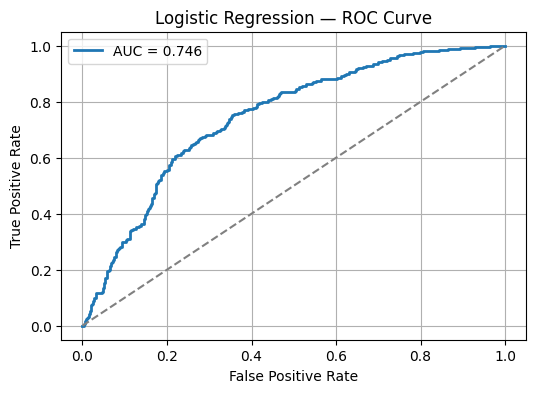


=== Evaluation: KNN ===


Outer CV (KNN): 100%|██████████| 5/5 [00:00<00:00,  5.73it/s]



>>> Best hyperparameters (last outer fold): {'clf__n_neighbors': 5, 'clf__weights': 'distance'}
Accuracy: 0.7565982404692082
ROC-AUC: 0.8584293193717277
Mean uncertainty: 0.5077067549416858
Uncertainty (Pred=0): 0.5331408865059032
Uncertainty (Pred=1): 0.48984784725433195
Confusion matrix:
 [[373 200]
 [ 49 401]]
              precision    recall  f1-score   support

           0       0.88      0.65      0.75       573
           1       0.67      0.89      0.76       450

    accuracy                           0.76      1023
   macro avg       0.78      0.77      0.76      1023
weighted avg       0.79      0.76      0.76      1023



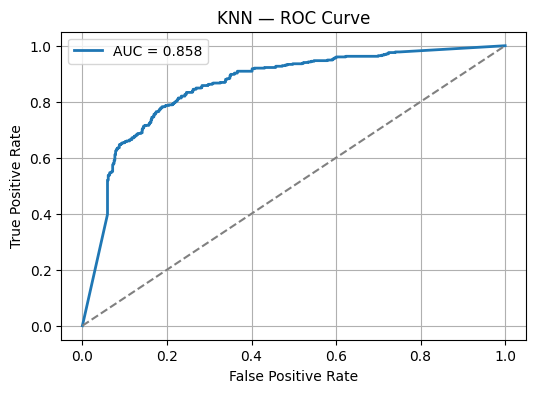


=== Evaluation: Random Forest ===


Outer CV (Random Forest): 100%|██████████| 5/5 [04:51<00:00, 58.23s/it]


>>> Best hyperparameters (last outer fold): {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': None}
Accuracy: 0.8455522971652004
ROC-AUC: 0.9032770990886174
Mean uncertainty: 0.8033331761354149
Uncertainty (Pred=0): 0.8147921704700853
Uncertainty (Pred=1): 0.7868813342692093
Confusion matrix:
 [[509  64]
 [ 94 356]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       573
           1       0.85      0.79      0.82       450

    accuracy                           0.85      1023
   macro avg       0.85      0.84      0.84      1023
weighted avg       0.85      0.85      0.84      1023



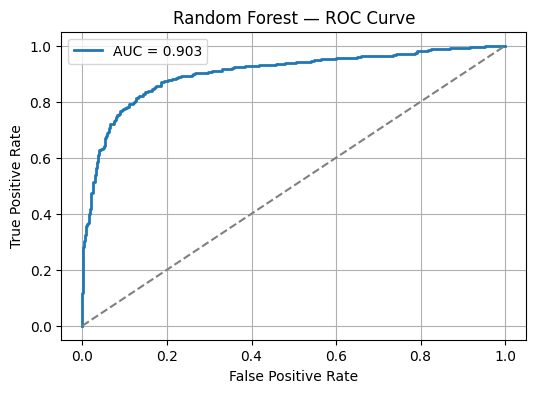


=== Evaluation: XGBoost ===


Outer CV (XGBoost): 100%|██████████| 5/5 [02:18<00:00, 27.61s/it]


>>> Best hyperparameters (last outer fold): {'clf__subsample': 0.7, 'clf__n_estimators': 400, 'clf__max_depth': 6, 'clf__learning_rate': 0.1, 'clf__colsample_bytree': 0.8}
Accuracy: 0.8582600195503421
ROC-AUC: 0.9125887143688192
Mean uncertainty: 0.4734795106309061
Uncertainty (Pred=0): 0.4546573598997038
Uncertainty (Pred=1): 0.4969761735217257
Confusion matrix:
 [[498  75]
 [ 70 380]]
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       573
           1       0.84      0.84      0.84       450

    accuracy                           0.86      1023
   macro avg       0.86      0.86      0.86      1023
weighted avg       0.86      0.86      0.86      1023



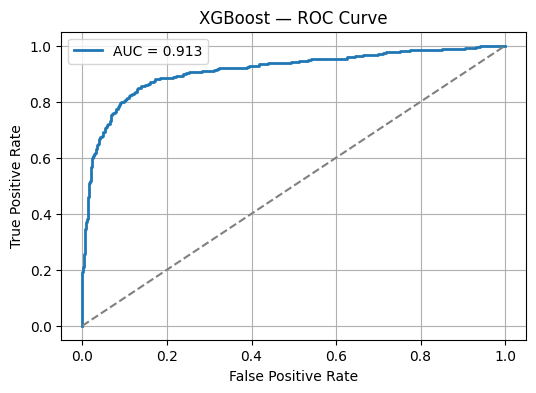


=== Evaluation: Gaussian Process ===


Outer CV (Gaussian Process):   0%|          | 0/5 [00:00<?, ?it/s]/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise


>>> Best hyperparameters (last outer fold): {'clf__kernel': 0.707**2 * RBF(length_scale=0.5) + WhiteKernel(noise_level=0.001), 'clf__n_restarts_optimizer': 0}
Accuracy: 0.841642228739003
ROC-AUC: 0.9171999224355245
Mean uncertainty: 0.7857703069332227
Uncertainty (Pred=0): 0.8128382384129884
Uncertainty (Pred=1): 0.7583293921456649
Confusion matrix:
 [[463 110]
 [ 52 398]]
              precision    recall  f1-score   support

           0       0.90      0.81      0.85       573
           1       0.78      0.88      0.83       450

    accuracy                           0.84      1023
   macro avg       0.84      0.85      0.84      1023
weighted avg       0.85      0.84      0.84      1023



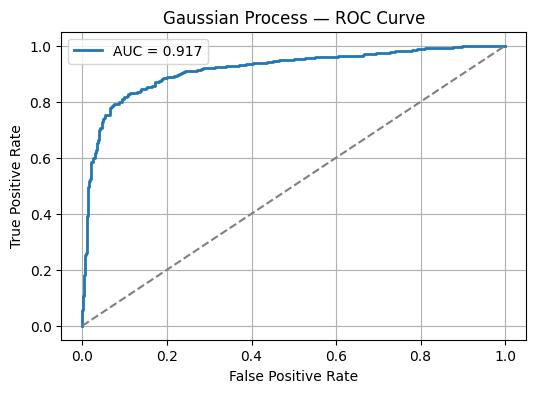


=== Summary Table ===


,Model,Accuracy,ROC-AUC,Mean Uncertainty,Uncertainty (Pred=0),Uncertainty (Pred=1)
0,Logistic Regression,0.699902,0.746236,0.828085,0.796435,0.872978
1,KNN,0.756598,0.858429,0.507707,0.533141,0.489848
2,Random Forest,0.845552,0.903277,0.803333,0.814792,0.786881
3,XGBoost,0.858260,0.912589,0.473480,0.454657,0.496976
4,Gaussian Process,0.841642,0.917200,0.785770,0.812838,0.758329


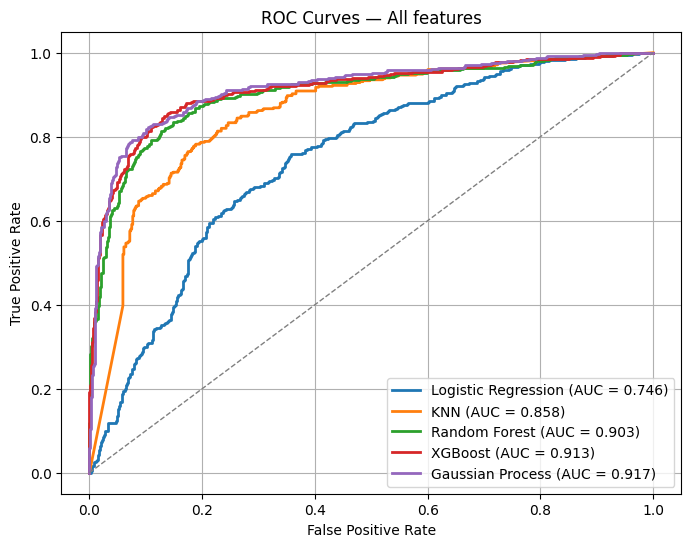

In [14]:

# Evaluation

evaluate_models_cv_with_tuning(X_resampled, y_resampled, "All features")
